# Solution: can you run the whole pass alone and send Anand a reconciliation his analyst can audit?

**Week 1, Wednesday afternoon, the escalated case, solution twin.** Anand has replied: "Send the reconciliation and the log before the day closes. My analyst checks it
tonight." The pass is the chain of steps the six chapters built to turn the raw export from the ERP, the
enterprise resource planning system Finance books orders in, into a clean file, with a log that names,
for every row it sets aside, the row's twin: the other copy of the same order, which stayed. This time
you write two of its pieces yourself: the identity rule, which decides what
makes two rows one order and which copy stays, and Monday's revenue tree recomputed on the clean file.
The revenue tree reads revenue = customers x orders per customer x revenue per order, with each branch
read as Q2's multiple of Q1.

**Who needs the answer.** Anand Iyer, the finance controller, passes the reconciliation to his analyst, who checks it tonight by
tying out every figure: she matches each one to the books, Finance's own record of Q1 at Rs 1,90,00,000,
line by line, so a rupee's difference is a finding. Marketing's rescue campaign for Retail-Plus, Kalpa's
paid membership tier, waits on whether Tuesday's finding survives the clean file: on the export as
delivered, Retail-Plus orders per customer fell 49 percent from Q1 to Q2, from 2.32 to 1.18. A
reconciliation the analyst cannot follow costs Anand's trust, and a finding nobody recomputes sends
Marketing after a fall that may be smaller than reported.

**The questions on the way.**

1. How many orders does the export hold?
2. What happens to the row whose amount will not convert, before the identity rule runs?
3. What makes two rows one order, and which copy stays?
4. After conversion, what should the pass do with the order that has no status and with the largest Q2 order?
5. Do the rows and the rupees both tie, and which moves walk Q1 down to the books?
6. On the clean file, how does each branch of the revenue tree move, and does Tuesday's finding survive?

Every placeholder is filled with its keyed option and the notebook runs clean. Under each step, one
line says why the other letters fail. The letters, in order: 1c 2a 3d 4c 5b 6d 7b 8a 9c.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

import re

def ok(row):
    """True when a row's amount converts to rupees."""
    return convert(row["amount"])[0] is not None

def per_customer(rows, q, seg):
    rs = [r for r in rows if r["quarter"] == q and r["segment"] == seg]
    return len(rs) / len({r["customer_id"] for r in rs})

print("helper and case functions loaded")

helper and case functions loaded


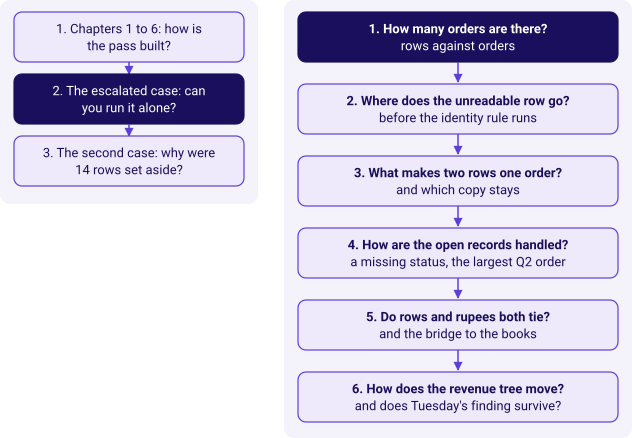

In [2]:
kit.side_by_side(
    kit.ladder(["Chapters 1 to 6: how is the pass built?", "The escalated case: can you run it alone?",
            "The second case: why were 14 rows set aside?"], lit=1, show=False),
    kit.vflow(["1. How many orders are there?\nrows against orders",
               "2. Where does the unreadable row go?\nbefore the identity rule runs",
               "3. What makes two rows one order?\nand which copy stays",
               "4. How are the open records handled?\na missing status, the largest Q2 order",
               "5. Do rows and rupees both tie?\nand the bridge to the books",
               "6. How does the revenue tree move?\nand does Tuesday's finding survive?"], lit=0, show=False),
)

## Step 1. How many orders does the export hold?

Anand's analyst will ask how many orders the export holds before she reads anything else. Count them.

In [3]:
raw = read_orders()
# TODO 1. Anand's analyst asks how many orders the export holds. Which count answers her?
#   a) len(raw)
#   b) len({r["customer_id"] for r in raw})
#   c) len({r["order_id"] for r in raw})
#   d) sum(1 for r in raw if ok(r))
orders_sent = len({r["order_id"] for r in raw})
print("Step 1: done")

Step 1: done


**Why the other letters fail.** c. An order is its order_id, so the distinct ids count the orders. a counts rows, copies included; b counts the 69 customers; d counts rows whose amount converts, copies included.

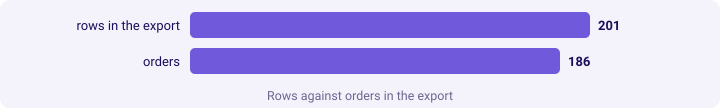

In [4]:
ids = sorted(r["order_id"] for r in raw)
by_sort = 1 + sum(1 for a, b in zip(ids, ids[1:]) if a != b)
kit.check("your count matches a second count: the sorted ids, one more at each change", orders_sent == by_sort, f"{orders_sent}")
kit.check("the export holds more rows than orders", len(raw) > orders_sent, f"{len(raw)} rows")
kit.bars([("rows in the export", len(raw)), ("orders", orders_sent)], title="Rows against orders in the export")

## Step 2. What happens to the row whose amount will not convert, before the identity rule runs?

One amount will not convert. The identity rule runs next, and it needs every row the ERP sent in front of it.

In [5]:
failed = []
# TODO 2. What does the pass do with that row before the identity rule runs?
#   a) failed = [r for r in raw if not ok(r)]
#   b) raw = [r for r in raw if ok(r)]
#   c) raw = [dict(r, amount=r["amount"] if r["amount"].isdigit() else "0") for r in raw]
#   d) raw = [dict(r, amount=str(convert(r["amount"])[0] or 0)) for r in raw]
failed = [r for r in raw if not ok(r)]
print("Step 2: done")

Step 2: done


**Why the other letters fail.** a. The row is counted and read, and the identity rule decides it next with its twin in view. b deletes the row before anyone knows it is a copy whose twin carries the value; c and d write a zero over the text, so the rule can no longer tell the copy from its twin, the coerced pass of chapter 4, which left Q1 Rs 1,790 short.

In [6]:
unreadable = [r["line"] for r in raw if not re.fullmatch(r"[0-9]+", r["amount"])]
kit.check("every row the ERP sent is still in the pass", len(raw) == len(read_orders()), f"{len(raw)} rows")
kit.check("the rows counted for reading are the ones a digit pattern cannot read",
          bool(failed) and [r["line"] for r in failed] == unreadable, f"{len(failed)} row")

## Step 3. What makes two rows one order, and which copy stays?

Write the rule that keeps one row per order. The two lines that decide are yours; the rest logs every row set aside with its reason and the line of the row that stayed.

In [7]:
def identity_rule(rows):
    """One row per order: the kept rows, and a set-aside log with a reason on every line."""
    kept, set_aside = {}, []
    for r in rows:
        # TODO 3. What makes two rows one order?
        #   a) r["line"]
        #   b) (r["customer_id"], r["amount"])
        #   c) tuple(sorted((f, v) for f, v in r.items() if f != "line"))
        #   d) r["order_id"]
        k = r["order_id"]
        if k not in kept:
            kept[k] = r
        # TODO 4. When does a later copy take the place of the one already kept?
        #   a) r["order_date"] > kept[k]["order_date"]
        #   b) r["amount"] > kept[k]["amount"]
        #   c) not ok(kept[k]) and ok(r)
        #   d) True
        elif not ok(kept[k]) and ok(r):
            set_aside.append(dict(kept[k], reason="copy whose amount does not convert", kept_line=r["line"]))
            kept[k] = r
        else:
            set_aside.append(dict(r, reason="second copy of the order", kept_line=kept[k]["line"]))
    return list(kept.values()), set_aside

kept, set_aside = identity_rule(raw)
print("Step 3: done")

Step 3: done


**Why the other letters fail.** d. The ERP issues one order_id per order. a makes every row unique, so nothing is set aside; b merges a real Rs 17,71,000 order from the Business segment, Kalpa's sales to companies, into an earlier one and misses the pair whose amounts differ; c misses the two pairs whose copies differ in one field. c. A later copy takes the kept one's place only when the kept one cannot be read and the later one can. a keeps whichever copy is dated later, which here keeps the unreadable copy and leaves Q1 Rs 1,790 short; b compares the amounts as text, so the unreadable copy wins in the same way; d keeps every last copy, which lands on the books only by file order and logs 14 readable copies as unreadable.

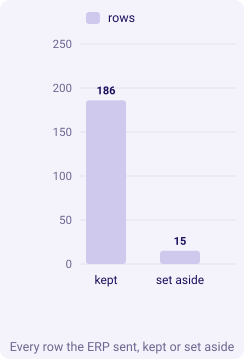

In [8]:
kept_ids = [r["order_id"] for r in kept]
kit.check("one kept row per order, and every order the export holds is kept",
          len(kept_ids) == len(set(kept_ids)) == orders_sent, f"{len(kept)} kept")
kit.check("rows reconcile: every row is kept or set aside", len(raw) == len(kept) + len(set_aside))
kit.check("every row logged as unreadable really is unreadable",
          all(not ok(r) for r in set_aside if r["reason"].startswith("copy whose amount")))
kit.check("Q1 over the kept rows equals the books", Q(kept, "Q1") == BOOKS_Q1, kit.rupees(Q(kept, "Q1")))
kit.columns(["kept", "set aside"], [("rows", [len(kept), len(set_aside)])], title="Every row the ERP sent, kept or set aside")

## Step 4. After conversion, what should the pass do with the order that has no status and with the largest Q2 order?

Convert the kept amounts with a rejects log, the list of amounts that fail with their line and reason, then make the two decisions the clean file still needs, one about the order with no status and one about the largest Q2 order, which comes from the Business segment, Kalpa's sales to companies, where every order runs to lakhs. A decision that keeps a record with a question on it writes a line in the flags log.

In [9]:
clean, rejects, flags = [], [], []
for r in kept:
    value, reason = convert(r["amount"])
    if value is None:
        rejects.append({"line": r["line"], "order_id": r["order_id"], "quarter": r["quarter"],
                        "amount": r["amount"], "field": "amount", "reason": reason})
    else:
        clean.append(dict(r, amount=value))

def flag(row, field, why):
    flags.append({"line": row["line"], "order_id": row["order_id"], "field": field, "why": why})

missing = [r for r in clean if not r["status"]]
# TODO 5. One kept order has no status. Which line keeps Q2 revenue whole and every status as the export recorded it?
#   a) clean = [r for r in clean if r not in missing]
#   b) for r in missing: flag(r, "status", "unknown")
#   c) for r in missing: r["status"] = "delivered"
#   d) for r in missing: r["status"] = "cancelled"
for r in missing: flag(r, "status", "unknown")

q2_sorted = sorted((r for r in clean if r["quarter"] == "Q2"), key=lambda r: r["amount"], reverse=True)
top, runner_up = q2_sorted[0], q2_sorted[1]
median_q2 = q2_sorted[len(q2_sorted) // 2]["amount"]
# TODO 6. The largest Q2 order is 1.66 times the next, from a Business account with orders in both quarters. Which line handles it?
#   a) clean = [r for r in clean if r is not top]
#   b) clean = [dict(r, amount=runner_up["amount"]) if r is top else r for r in clean]
#   c) clean = [dict(r, amount=min(r["amount"], 3 * median_q2)) for r in clean]
#   d) flag(top, "amount", "largest Q2 order; shown with and without")
flag(top, "amount", "largest Q2 order; shown with and without")
print("Step 4: done")

Step 4: done


**Why the other letters fail.** b. The order stays in revenue, its status stays blank, and the flags log says why. a drops a booked order; c records a delivery nobody recorded; d records a cancellation nobody recorded. d. The order is real, so it stays, flagged, and Q2 is shown with and without it. a removes Rs 29,45,460 of booked revenue; b writes the next order's amount over a real one; c caps every order at three times the Q2 median, which cuts every Business order.

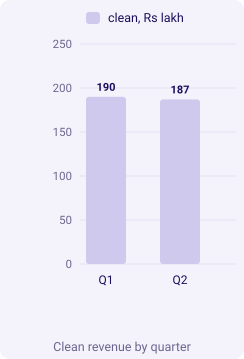

In [10]:
q2 = [r for r in clean if r["quarter"] == "Q2"]
q2_kept = [r for r in kept if r["quarter"] == "Q2"]
kit.check("the rejects log is empty: every kept amount converts", not rejects)
kit.check("every kept order is still in the clean file", len(clean) == len(kept), f"{len(clean)} orders")
kit.check("Q2 is every rupee the kept Q2 rows carry", Q(q2, "Q2") == Q(q2_kept, "Q2"), kit.rupees(Q(q2, "Q2")))
kit.check("no status was filled in or thrown away",
          sum(1 for r in clean if not r["status"]) == sum(1 for r in kept if not r["status"]))
kit.check("the delivered count is what the export recorded",
          sum(1 for r in q2 if r["status"] == "delivered") == sum(1 for r in q2_kept if r["status"] == "delivered"))
kit.check("each record kept with a question on it has a line in the flags log", len(flags) == 2, f"{len(flags)} lines")
kit.columns(["Q1", "Q2"], [("clean, Rs lakh", [Q(clean, "Q1") / 1e5, Q(clean, "Q2") / 1e5])],
            fmt=lambda v: f"{v:,.0f}", title="Clean revenue by quarter")

## Step 5. Do the rows and the rupees both tie, and which moves walk Q1 down to the books?

Rows tie on any pass that logs what it sets aside, including chapter 6's colleague, who kept the first copy and then converted, so the rupee test is the one that has to tell the two passes apart. The check cell then draws the bridge, which walks Q1 from the export down to the books in moves, each move one cause with its rupees.

In [11]:
def colleague_pass(rows):
    """Chapter 6's colleague: repeated ids out first, keeping the first copy, then conversion."""
    seen, first, aside = set(), [], []
    for r in rows:
        (aside if r["order_id"] in seen else first).append(r)
        seen.add(r["order_id"])
    return ([dict(r, amount=convert(r["amount"])[0]) for r in first if ok(r)],
            aside + [r for r in first if not ok(r)])

def rupee_test(clean_rows, aside_rows):
    # TODO 7. Which rupee test passes a right pass and fails the colleague's, which is Rs 1,790 short?
    #   a) round(Q(clean_rows, "Q1") / 1e7, 2) == round(BOOKS_Q1 / 1e7, 2)
    #   b) Q(raw, "Q1") - Q(aside_rows, "Q1") == BOOKS_Q1
    #   c) Q(clean_rows, "Q1") < Q(raw, "Q1")
    #   d) abs(Q(clean_rows, "Q1") - BOOKS_Q1) < 0.01 * BOOKS_Q1
    return Q(raw, "Q1") - Q(aside_rows, "Q1") == BOOKS_Q1

col_clean, col_aside = colleague_pass(raw)
print("Step 5: done")

Step 5: done


**Why the other letters fail.** b. The export's Q1 less the rupees set aside equals the books only when the right copy stayed. a rounds the Rs 1,790 away; c holds for any pass that removes anything; d allows Rs 1,90,000 of error, about a hundred times the gap it has to catch.

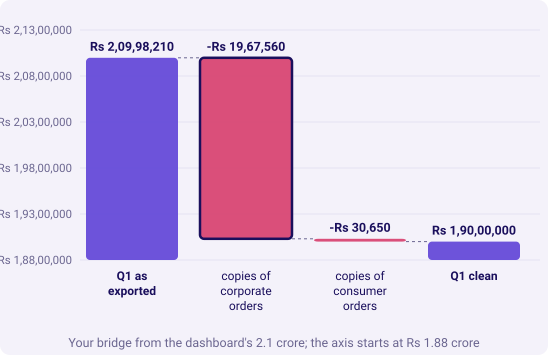

In [12]:
kit.check("rows tie on your pass", len(raw) == len(clean) + len(set_aside) + len(rejects))
kit.check("rows tie on the colleague's pass too", len(raw) == len(col_clean) + len(col_aside))
kit.check("your rupee test passes your pass", rupee_test(clean, set_aside + rejects))
kit.check("and fails the colleague's", not rupee_test(col_clean, col_aside))
q1_aside = [r for r in set_aside if r["quarter"] == "Q1"]
kit.bridge(("Q1 as exported", Q(raw, "Q1")),
           [("copies of corporate orders", -Q([r for r in q1_aside if r["segment"] == "Business"], "Q1")),
            ("copies of consumer orders", -Q([r for r in q1_aside if r["segment"] != "Business"], "Q1"))],
           end_label="Q1 clean", lit=(0,), lo=18800000,
           title="Your bridge from the dashboard's 2.1 crore; the axis starts at Rs 1.88 crore")

## Step 6. On the clean file, how does each branch of the revenue tree move, and does Tuesday's finding survive?

Recompute Monday's revenue tree on the clean file: customers, orders per customer and revenue per order for each quarter, then each branch's Q2 multiple of Q1. On the export as delivered, Tuesday read the multiples as customers x1.000, orders per customer x0.754, revenue per order x1.180 and revenue x0.890, and reported Retail-Plus orders per customer falling from 2.32 to 1.18.

In [13]:
def leaves(rows, q):
    """Monday's tree for one quarter: customers, orders per customer, revenue per order, revenue."""
    rs = [r for r in rows if r["quarter"] == q]
    # TODO 8. Which count is the tree's customers branch?
    #   a) len({r["customer_id"] for r in rs})
    #   b) len(rs)
    #   c) len({r["order_id"] for r in rs})
    #   d) len({(r["customer_id"], r["order_date"]) for r in rs})
    customers = len({r["customer_id"] for r in rs})
    return customers, len(rs) / customers, Q(rs, q) / len(rs), Q(rs, q)

t1, t2 = leaves(clean, "Q1"), leaves(clean, "Q2")
# TODO 9. Which line gives each branch's Q2 multiple of Q1, the way the tree multiplies back to revenue?
#   a) [b - a for a, b in zip(t1, t2)]
#   b) [a / b for a, b in zip(t1, t2)]
#   c) [b / a for a, b in zip(t1, t2)]
#   d) [(b - a) / b for a, b in zip(t1, t2)]
moves = [b / a for a, b in zip(t1, t2)]
print("Step 6: done")

Step 6: done


**Why the other letters fail.** a. Customers are the distinct buyers in the quarter, 69 in each. b counts orders as customers, Monday's first trap; c counts orders again; d counts each customer once per order date, which is visits. c. A branch's multiple is Q2 over Q1, and the three multiples multiply back to revenue's. a gives differences, which do not multiply; b gives Q1 over Q2, the tree read backwards; d gives the change as a share of Q2, which does not multiply back either.

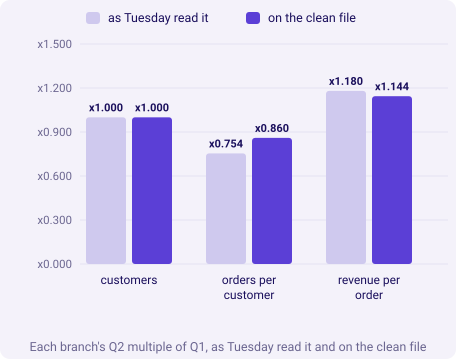

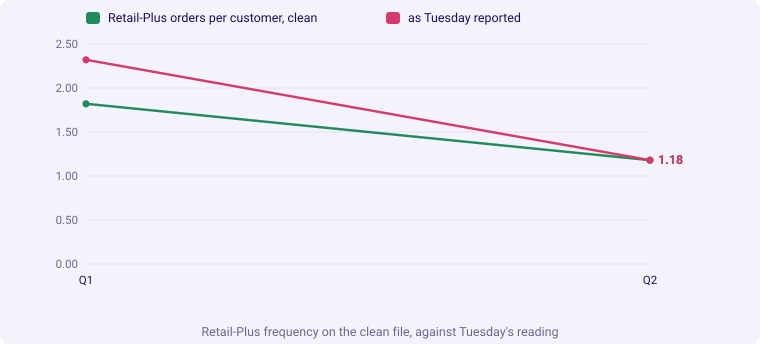

In [14]:
buyers = {q: Counter(r["customer_id"] for r in clean if r["quarter"] == q) for q in ("Q1", "Q2")}
kit.check("the customers branch matches a Counter of the buyers in each quarter",
          (t1[0], t2[0]) == (len(buyers["Q1"]), len(buyers["Q2"])))
kit.check("the three branch multiples multiply back to revenue's", abs(moves[0] * moves[1] * moves[2] - moves[3]) < 1e-9)
kit.check("revenue's multiple is Q2 over Q1 on the clean file", abs(moves[3] - Q(clean, "Q2") / Q(clean, "Q1")) < 1e-9,
          f"x{moves[3]:.3f}")
kit.columns(["customers", "orders per customer", "revenue per order"],
            [("as Tuesday read it", [1.000, 0.754, 1.180]), ("on the clean file", list(moves[:3]))],
            fmt=lambda v: f"x{v:.3f}", title="Each branch's Q2 multiple of Q1, as Tuesday read it and on the clean file")
rp = [per_customer(clean, q, "Retail-Plus") for q in ("Q1", "Q2")]
kit.line(["Q1", "Q2"], [("Retail-Plus orders per customer, clean", [round(x, 2) for x in rp], "good"),
                        ("as Tuesday reported", [2.32, 1.18], "bad")], fmt=lambda v: f"{v:.2f}",
         title="Retail-Plus frequency on the clean file, against Tuesday's reading")
kit.check_summary()

**Post** your nine letters in order, then the note to Finance in under 120 words: numbers first,
which figure is right and why, the two reconciliations, the two flags, what the recomputed tree
says, and whether Tuesday's finding survives.